In [1]:
# =========================
# Step 1: Import libraries
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Step 2: Load the dataset
# =========================
file_path = "D:\\Assignments questions\\Random Forest\\glass.xlsx"   # update path if needed
df = pd.read_excel(file_path)

# =========================
# Step 3: Basic Information
# =========================
print("Shape of dataset:", df.shape)       # rows and columns
print("\nColumns:", df.columns.tolist())   # column names
print("\nData Types:\n", df.dtypes)        # datatypes
print("\nFirst 5 rows:\n", df.head())      # preview



Shape of dataset: (214, 10)

Columns: ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type']

Data Types:
 RI      float64
Na      float64
Mg      float64
Al      float64
Si      float64
K       float64
Ca      float64
Ba      float64
Fe      float64
Type      int64
dtype: object

First 5 rows:
         RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type
0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0     1
1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0     1
2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0     1
3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0     1
4  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0     1


In [2]:
# =========================
# Step 4: Summary Statistics
# =========================
print("\nSummary Statistics:\n", df.describe())

# =========================
# Step 5: Check for Missing Values
# =========================
print("\nMissing values per column:\n", df.isnull().sum())

# =========================
# Step 6: Check for Duplicates
# =========================
print("\nDuplicate rows:", df.duplicated().sum())




Summary Statistics:
                RI          Na          Mg          Al          Si           K  \
count  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000   
mean     1.518365   13.407850    2.684533    1.444907   72.650935    0.497056   
std      0.003037    0.816604    1.442408    0.499270    0.774546    0.652192   
min      1.511150   10.730000    0.000000    0.290000   69.810000    0.000000   
25%      1.516522   12.907500    2.115000    1.190000   72.280000    0.122500   
50%      1.517680   13.300000    3.480000    1.360000   72.790000    0.555000   
75%      1.519157   13.825000    3.600000    1.630000   73.087500    0.610000   
max      1.533930   17.380000    4.490000    3.500000   75.410000    6.210000   

               Ca          Ba          Fe        Type  
count  214.000000  214.000000  214.000000  214.000000  
mean     8.956963    0.175047    0.057009    2.780374  
std      1.423153    0.497219    0.097439    2.103739  
min      5.430000    0.0

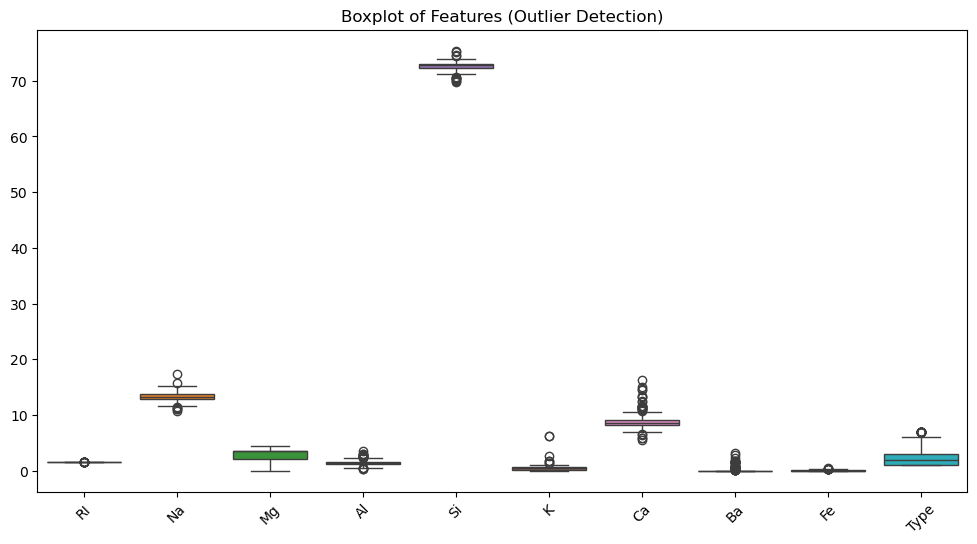


Unique values in 'Type': [1 2 3 5 6 7]


In [3]:
# =========================
# Step 7: Outlier Detection
# =========================
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Boxplot of Features (Outlier Detection)")
plt.show()

# =========================
# Step 8: Inconsistencies
# =========================
# For categorical target column (e.g., "Type"), check unique values
if 'Type' in df.columns:
    print("\nUnique values in 'Type':", df['Type'].unique())


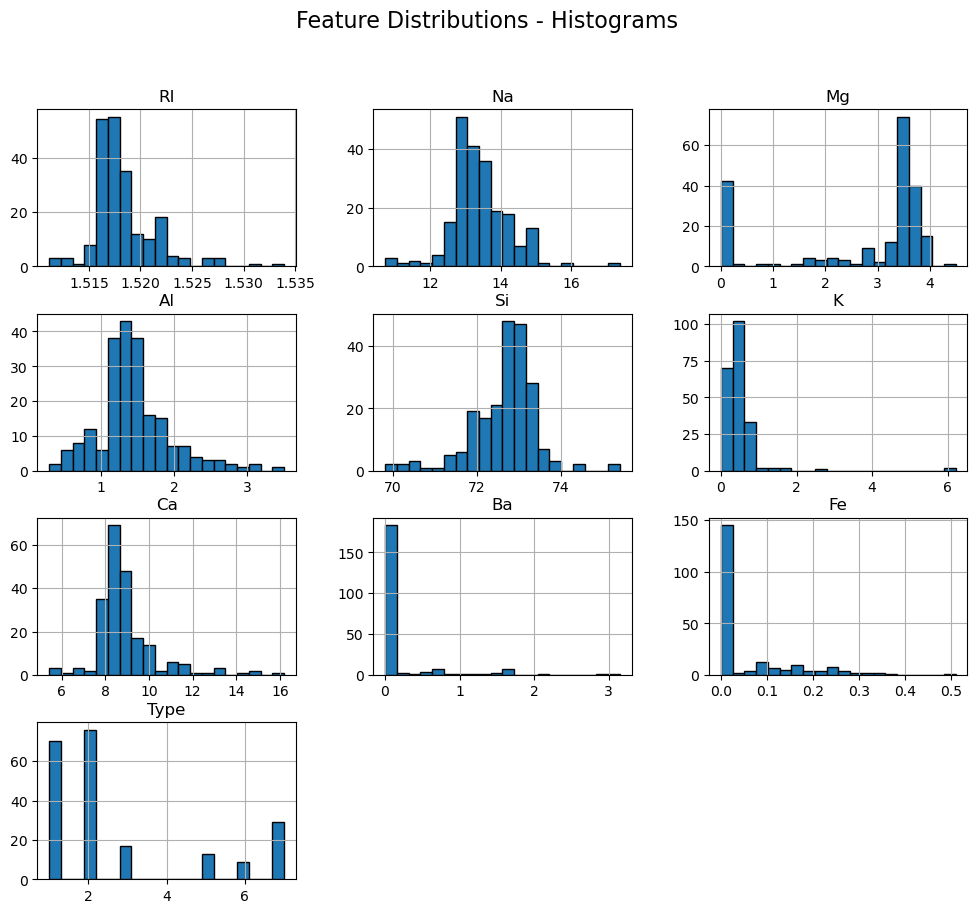

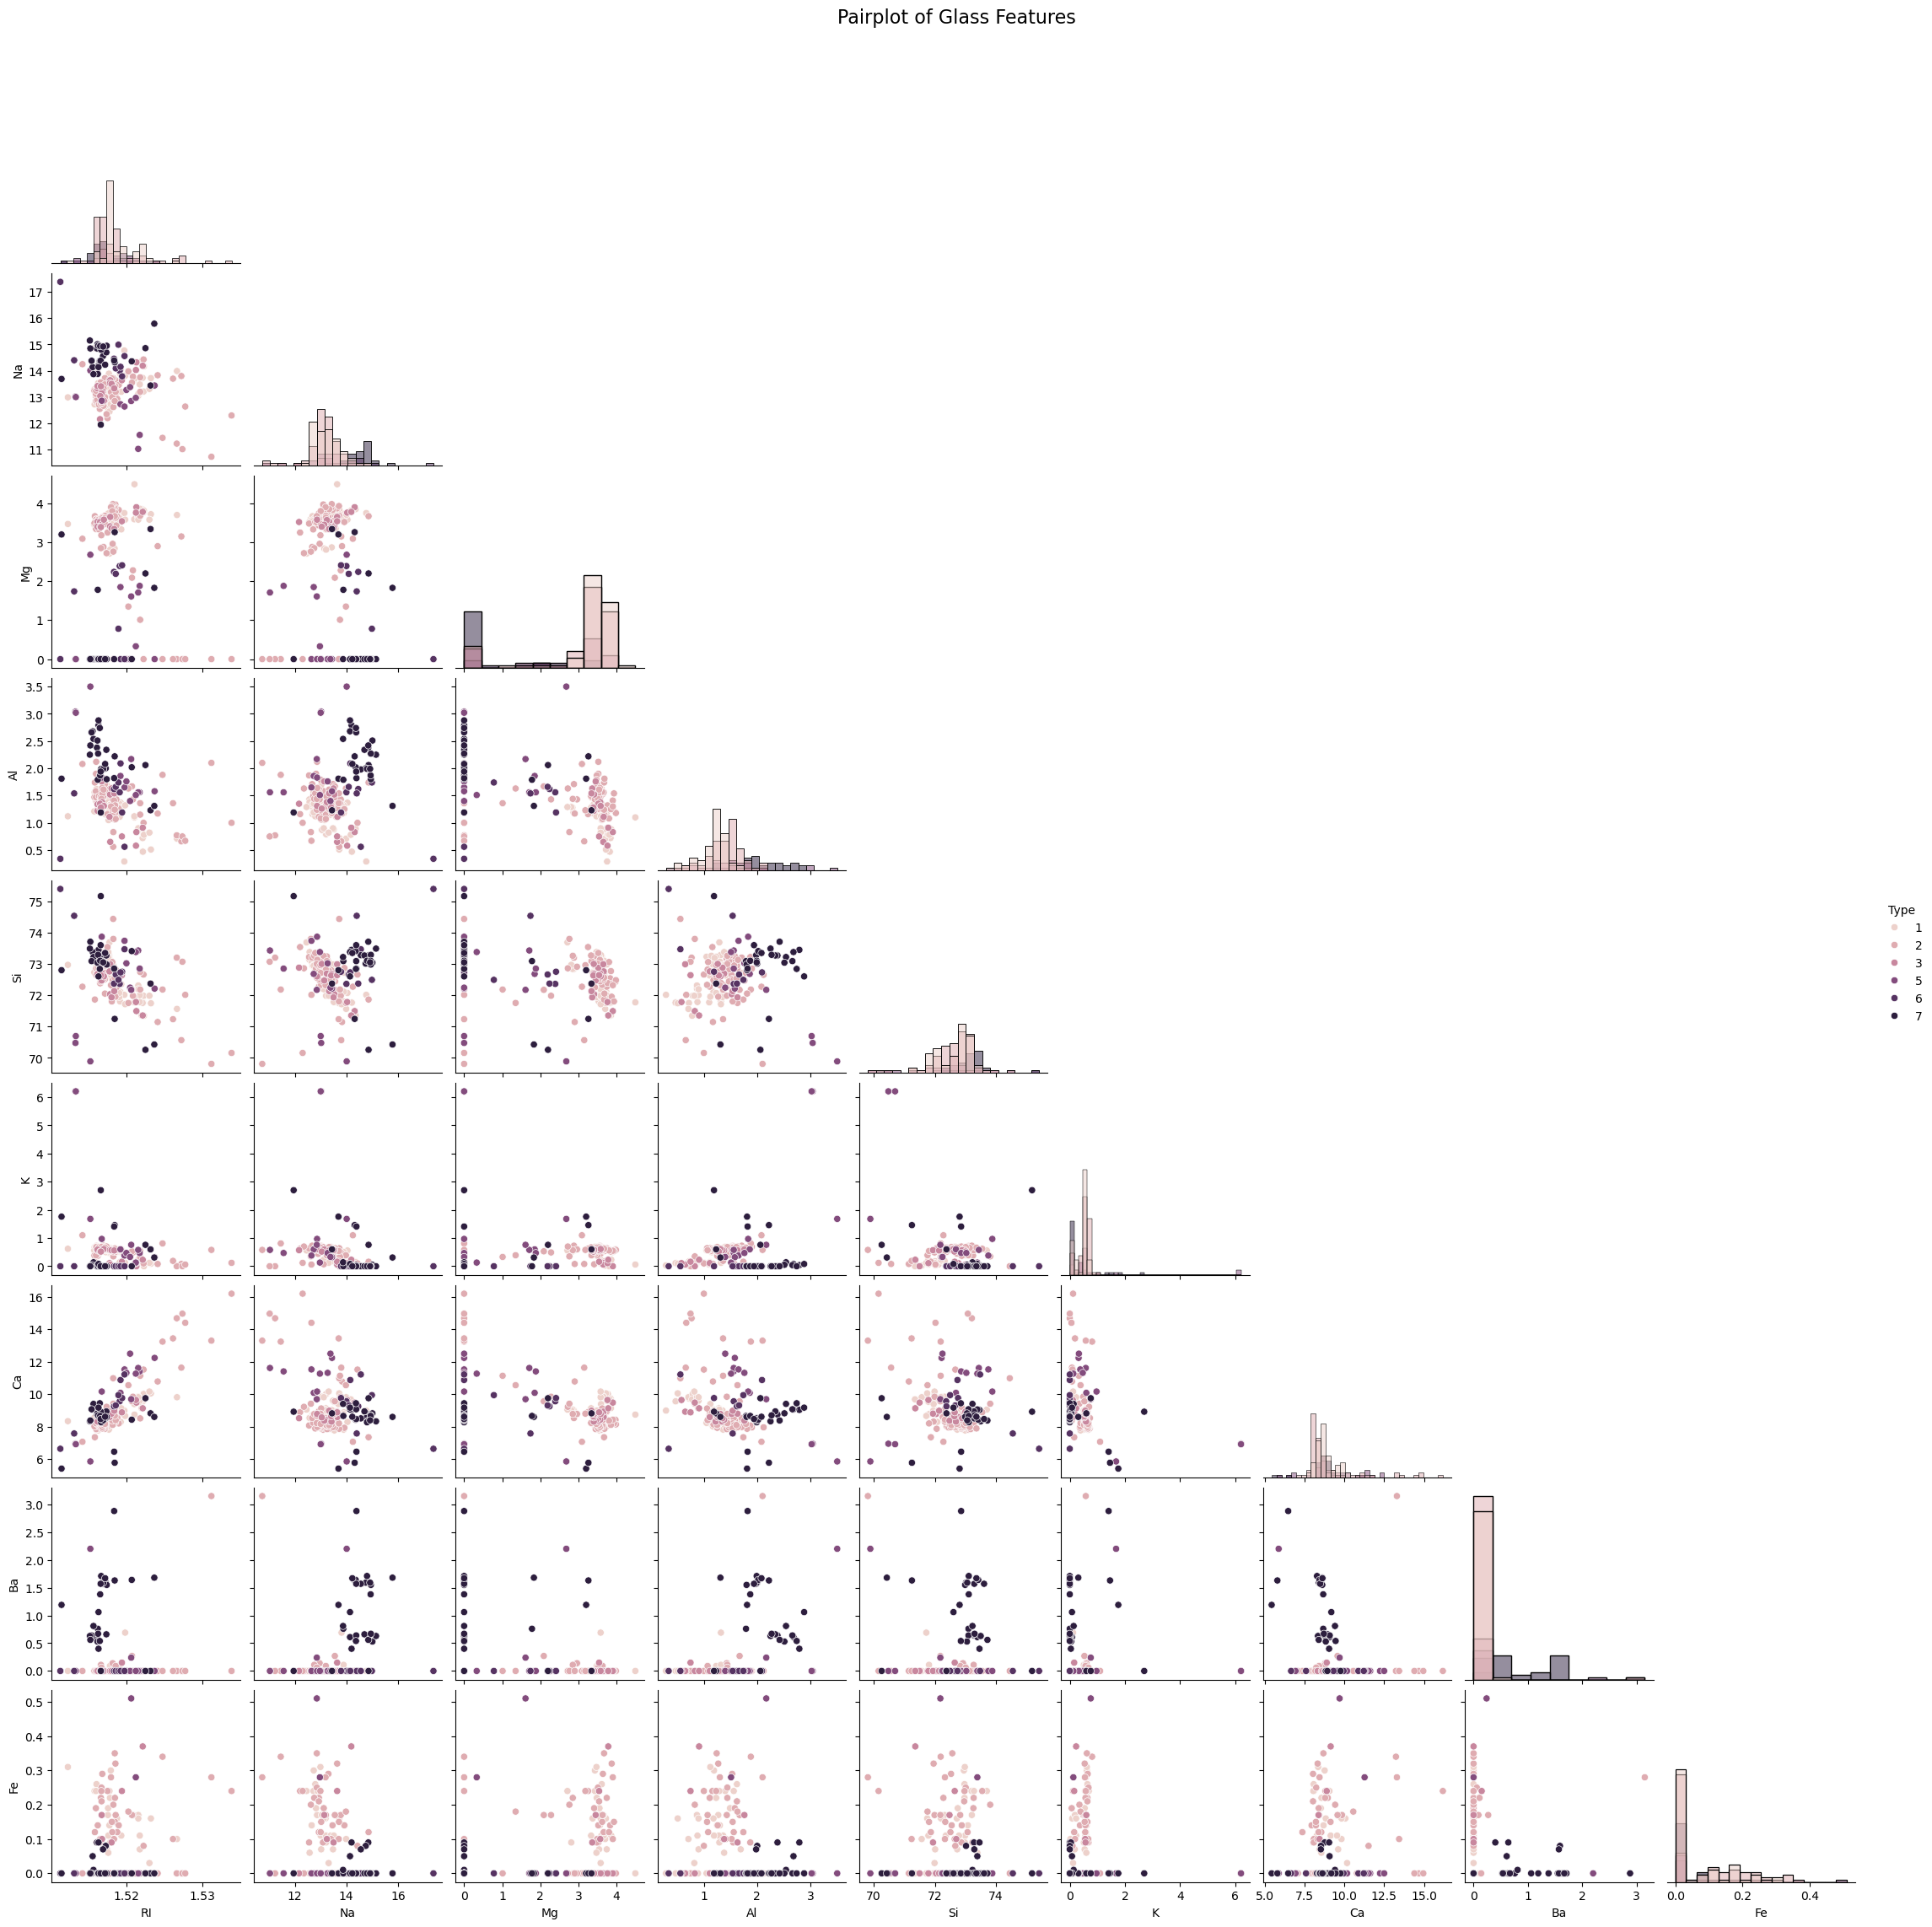

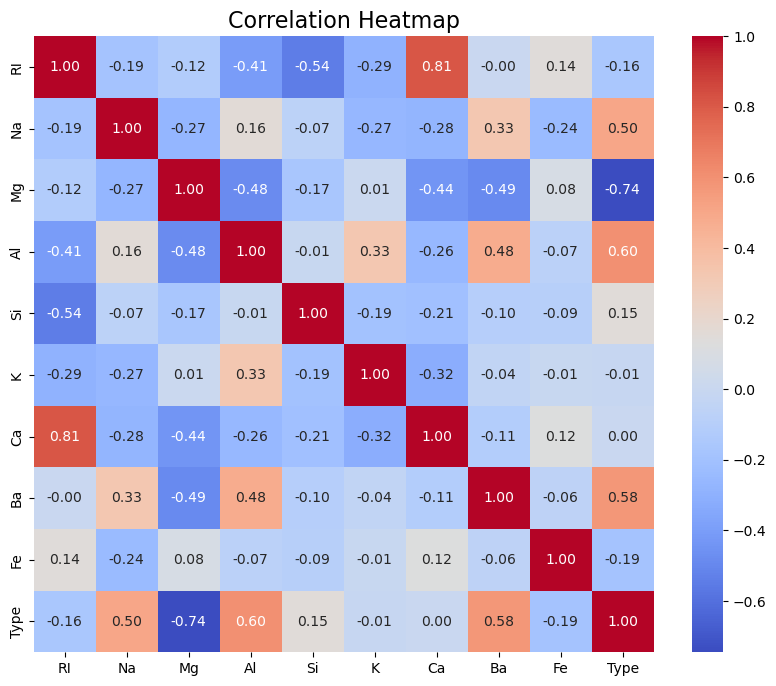

In [5]:
# =========================
# Step 1: Import libraries
# =========================
import matplotlib.pyplot as plt
import seaborn as sns


# =========================
# Step 2: Histograms
# =========================
df.hist(figsize=(12, 10), bins=20, edgecolor="black")
plt.suptitle("Feature Distributions - Histograms", fontsize=16)
plt.show()


# =========================
# Step 4: Pairplot
# =========================
# Pairplot helps visualize feature relationships
sns.pairplot(df, hue="Type", diag_kind="hist", corner=True)
plt.suptitle("Pairplot of Glass Features", y=1.02, fontsize=16)
plt.show()

# =========================
# Step 5: Correlation Heatmap
# =========================
plt.figure(figsize=(10,8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap", fontsize=16)
plt.show()


In [6]:
# Check missing values
print(df.isnull().sum())

# If missing values exist, decide strategy
# Example: Fill with mean for numerical, mode for categorical
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        df[col].fillna(df[col].mean(), inplace=True)
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values after treatment:\n", df.isnull().sum())


RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64
Missing values after treatment:
 RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64


C:\Users\munig\AppData\Local\Temp\ipykernel_10340\3720663517.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [7]:
from sklearn.preprocessing import LabelEncoder

# If target column is categorical
if df['Type'].dtype == 'object':
    le = LabelEncoder()
    df['Type'] = le.fit_transform(df['Type'])

print(df['Type'].unique())


[1 2 3 5 6 7]


In [8]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop("Type", axis=1)
y = df["Type"]

# Standardization (z-score: mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [9]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

print("Before SMOTE:", y.value_counts())
print("After SMOTE:", pd.Series(y_resampled).value_counts())


Before SMOTE: Type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64
After SMOTE: Type
1    76
2    76
3    76
5    76
6    76
7    76
Name: count, dtype: int64


In [10]:
# ===============================
# Step 1: Import libraries
# ===============================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# ===============================
# Step 2: Split train/test
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.3, random_state=42, stratify=y_resampled
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

# ===============================
# Step 3: Train Random Forest
# ===============================
rf_model = RandomForestClassifier(
    n_estimators=100,       # number of trees
    random_state=42,
    class_weight="balanced" # handle imbalance (extra safety)
)

rf_model.fit(X_train, y_train)

# ===============================
# Step 4: Predictions
# ===============================
y_pred = rf_model.predict(X_test)

# ===============================
# Step 5: Evaluation
# ===============================
print(" Random Forest Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision (macro):", precision_score(y_test, y_pred, average='macro'))
print("Recall (macro):", recall_score(y_test, y_pred, average='macro'))
print("F1-score (macro):", f1_score(y_test, y_pred, average='macro'))

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Training set size: (319, 9)
Testing set size: (137, 9)
 Random Forest Model Performance:
Accuracy: 0.8832116788321168
Precision (macro): 0.8907495252529353
Recall (macro): 0.8830698287220026
F1-score (macro): 0.8818430629617361

Classification Report:
               precision    recall  f1-score   support

           1       0.70      0.86      0.78        22
           2       0.94      0.70      0.80        23
           3       0.90      0.83      0.86        23
           5       0.88      0.96      0.92        23
           6       0.96      1.00      0.98        23
           7       0.96      0.96      0.96        23

    accuracy                           0.88       137
   macro avg       0.89      0.88      0.88       137
weighted avg       0.89      0.88      0.88       137


Confusion Matrix:
 [[19  1  2  0  0  0]
 [ 4 16  0  2  1  0]
 [ 4  0 19  0  0  0]
 [ 0  0  0 22  0  1]
 [ 0  0  0  0 23  0]
 [ 0  0  0  1  0 22]]


In [13]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# Bagging with Decision Tree
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)


bagging_model.fit(X_train, y_train)
y_pred_bagging = bagging_model.predict(X_test)

print(" Bagging Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_bagging))
print("Precision:", precision_score(y_test, y_pred_bagging, average='macro'))
print("Recall:", recall_score(y_test, y_pred_bagging, average='macro'))
print("F1-score:", f1_score(y_test, y_pred_bagging, average='macro'))


 Bagging Performance:
Accuracy: 0.8905109489051095
Precision: 0.8930555555555556
Recall: 0.8903162055335968
F1-score: 0.885044914552802


In [14]:
from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

ada_model.fit(X_train, y_train)
y_pred_ada = ada_model.predict(X_test)

print(" AdaBoost Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_ada))
print("Precision:", precision_score(y_test, y_pred_ada, average='macro'))
print("Recall:", recall_score(y_test, y_pred_ada, average='macro'))
print("F1-score:", f1_score(y_test, y_pred_ada, average='macro'))


 AdaBoost Performance:
Accuracy: 0.6131386861313869
Precision: 0.5789251600614788
Recall: 0.613965744400527
F1-score: 0.5556686898715885


In [18]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print(" Gradient Boosting Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb, average='macro'))
print("Recall:", recall_score(y_test, y_pred_gb, average='macro'))
print("F1-score:", f1_score(y_test, y_pred_gb, average='macro'))


 Gradient Boosting Performance:
Accuracy: 0.8686131386861314
Precision: 0.8685412403795317
Recall: 0.8669301712779974
F1-score: 0.8656235829486095


In [19]:
'''1. Bagging vs Boosting
Bagging:
Trains many models at the same time (parallel).
Each model gets random data samples.
Final result = majority vote or average.
Example: Random Forest.
Use: Reduces overfitting (variance).
2.Boosting:
Trains models one after another (sequential).
Each new model focuses on the mistakes of the previous one.
Final result = combined strong model.
Examples: AdaBoost, Gradient Boosting, XGBoost.
Use: Reduces bias (makes weak learners strong).'''

'1. Bagging vs Boosting\nBagging:\nTrains many models at the same time (parallel).\nEach model gets random data samples.\nFinal result = majority vote or average.\nExample: Random Forest.\nUse: Reduces overfitting (variance).\n2.Boosting:\nTrains models one after another (sequential).\nEach new model focuses on the mistakes of the previous one.\nFinal result = combined strong model.\nExamples: AdaBoost, Gradient Boosting, XGBoost.\nUse: Reduces bias (makes weak learners strong).'

In [ ]:
Handling Imbalanced Data
Problem: Some classes have many samples, others very few → model favors majority class.
Solutions:
Oversampling minority class (SMOTE creates extra samples).
Undersampling majority class (reduce big class).
Class weights → give more importance to minority class in training.
Use better metrics like Precision, Recall, F1 (not just accuracy).